# UdaSense: Optimized Object Recognition

## Notebook 1: Baseline Performance

In this notebook, you'll establish the baseline performance of the computer vision model. This will serve as the reference point for your optimization efforts.

Remember, the CTO has set specific requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

### Step 1. Set up the environment

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path

# Resolve the absolute path of the *project root* inside project-showroom
# Adjust `project_showroom_root` to your layout if needed
project_showroom_root = Path.cwd().resolve()

# Add the udasense project root to Python path
udasense_root = project_showroom_root # / "projects/model-opt/UdaSense-sense"  # or whatever the folder is called
sys.path.insert(0, str(udasense_root))

print("Added to PYTHONPATH:", udasense_root)

# Set current working directory to udasense project root
%cd {udasense_root}
print("Current working directory:", Path.cwd())

Added to PYTHONPATH: /home/oliver/project-showroom/projects/model-opt/udaci-sense
/home/oliver/project-showroom/projects/model-opt/udaci-sense
Current working directory: /home/oliver/project-showroom/projects/model-opt/udaci-sense


In [3]:
# Import libraries
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset

# Import custom modules
from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, print_model_summary, train_model
from utils.evaluation import calculate_confusion_matrix, evaluate_model_metrics
from utils.visualization import plot_confusion_matrix, plot_training_history, plot_weight_distribution

In [4]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

# Set device to cuda, if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 4070 Laptop GPU)']
Using device: cuda


In [5]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    # Basic seed setting
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For some PyTorch operations
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    # For DataLoader workers
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

In [6]:
# Create directories
model_type = "baseline_mobilenet"
models_dir = f"./models/{model_type}"
models_ckp_dir = f"{models_dir}/checkpoints"
results_dir = f"./results/{model_type}"

os.makedirs(models_ckp_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Created directories:\n- {models_ckp_dir}\n- {results_dir}")

Created directories:
- ./models/baseline_mobilenet/checkpoints
- ./results/baseline_mobilenet


### Step 2. Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


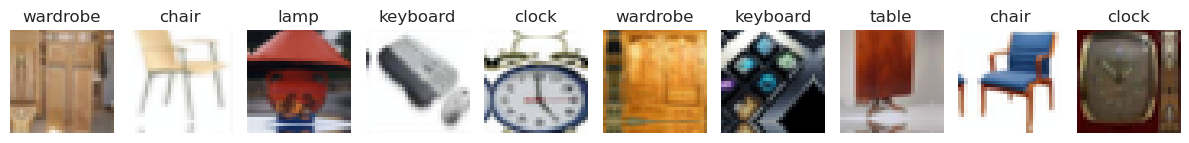


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


Traceback (most recent call last):
  File "/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/oliver/anaconda3/envs/pytorch_env/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-smcaayel'


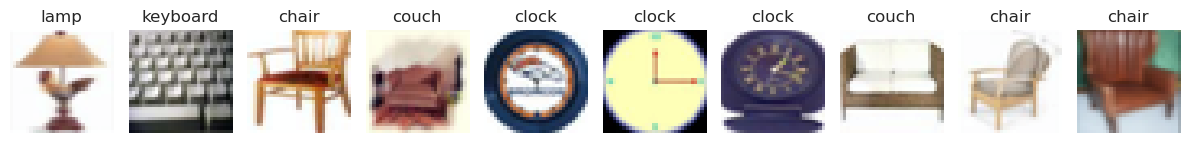

In [6]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=4,
)

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Train the baseline model

In [7]:
# Initialize model
model = MobileNetV3_Household().to(device)
print_model_summary(model)

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [ ]:
# Define training configuration
num_epochs = 100
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,  # Note that MobileNet is sensitive to high LRs
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,  # Peak learning rate
    steps_per_epoch=len(train_loader),
    epochs=num_epochs,
    pct_start=0.3,  # Spend 30% of training time warming up
    div_factor=25,  # Initial LR is max_lr/25
    final_div_factor=1000  # Final LR is max_lr/1000
)

training_config = {
    'num_epochs': num_epochs,
    'criterion': criterion,
    'optimizer': optimizer,
    'scheduler': None, # scheduler,
    'patience': 10,
    'device': device
}

In [10]:
# Train model given the training_config
training_stats, best_accuracy, best_epoch = train_model(
    model,
    train_loader,
    test_loader,
    training_config,
    checkpoint_path=f"{models_ckp_dir}/model.pth",
)

# Save training statistics
with open(f"{results_dir}/training_stats.json", 'w') as f:
    json.dump(training_stats, f, indent=4)

Total parameters: 1,528,106
Training with standard method for 100 epochs


Epoch 1/100 [Test]: 100%|██████████| 8/8 [00:00<00:00, 22.60it/s, loss=1.4, acc=64.4] 


Epoch 1/100 - Train Loss: 1.5997, Train Acc: 52.76%, Test Loss: 1.0487, Test Acc: 64.40%, LR: 0.000200, Time: 4.83s
New best model! Saving... (64.40%)
Model saved to ./models/baseline_mobilenet/checkpoints/model.pth


Epoch 2/100 [Test]: 100%|██████████| 8/8 [00:00<00:00, 25.28it/s, loss=0.991, acc=75]  


Epoch 2/100 - Train Loss: 0.7637, Train Acc: 73.74%, Test Loss: 0.7434, Test Acc: 75.00%, LR: 0.000200, Time: 4.01s
New best model! Saving... (75.00%)
Model saved to ./models/baseline_mobilenet/checkpoints/model.pth


...

Epoch 26/100 - Train Loss: 0.0466, Train Acc: 98.60%, Test Loss: 0.6091, Test Acc: 86.90%, LR: 0.000200, Time: 4.00s


Epoch 27/100 [Test]: 100%|██████████| 8/8 [00:00<00:00, 25.56it/s, loss=0.778, acc=86.8]


Epoch 27/100 - Train Loss: 0.0380, Train Acc: 98.82%, Test Loss: 0.5838, Test Acc: 86.80%, LR: 0.000200, Time: 3.99s


Epoch 28/100 [Test]: 100%|██████████| 8/8 [00:00<00:00, 25.07it/s, loss=0.855, acc=84.8]


Epoch 28/100 - Train Loss: 0.0786, Train Acc: 97.24%, Test Loss: 0.6410, Test Acc: 84.80%, LR: 0.000200, Time: 4.01s
Early stopping at epoch 28. No improvement for 10 epochs.
Training completed. Best accuracy: 88.80%
Best model saved as './models/baseline_mobilenet/checkpoints/model.pth' at epoch 18


### Step 4. Evaluate the baseline model

Evaluating model's performance on all metrics...


Evaluating accuracy: 100%|██████████| 8/8 [00:00<00:00, 14.21it/s]


DEBUG[evaluate_model_metrics]: Completed accuracy evaluation.


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 20.98it/s]


DEBUG[evaluate_per_class_accuracy]: Calculating per-class accuracy in evaluation function...
DEBUG[evaluate_per_class_accuracy]: Completed per-class accuracy calculation.
DEBUG[evaluate_model_metrics]: Completed per-class accuracy evaluations.
DEBUG[evaluate_model_metrics]: Completed inference time measurement.
DEBUG[evaluate_model_metrics]: Completed model size measurement.
DEBUG[evaluate_model_metrics]: Completed memory usage measurement.
Baseline metrics saved at ./results/baseline_mobilenet/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 20.73it/s]


Confusion matrix saved to ./results/baseline_mobilenet/confusion_matrix.png


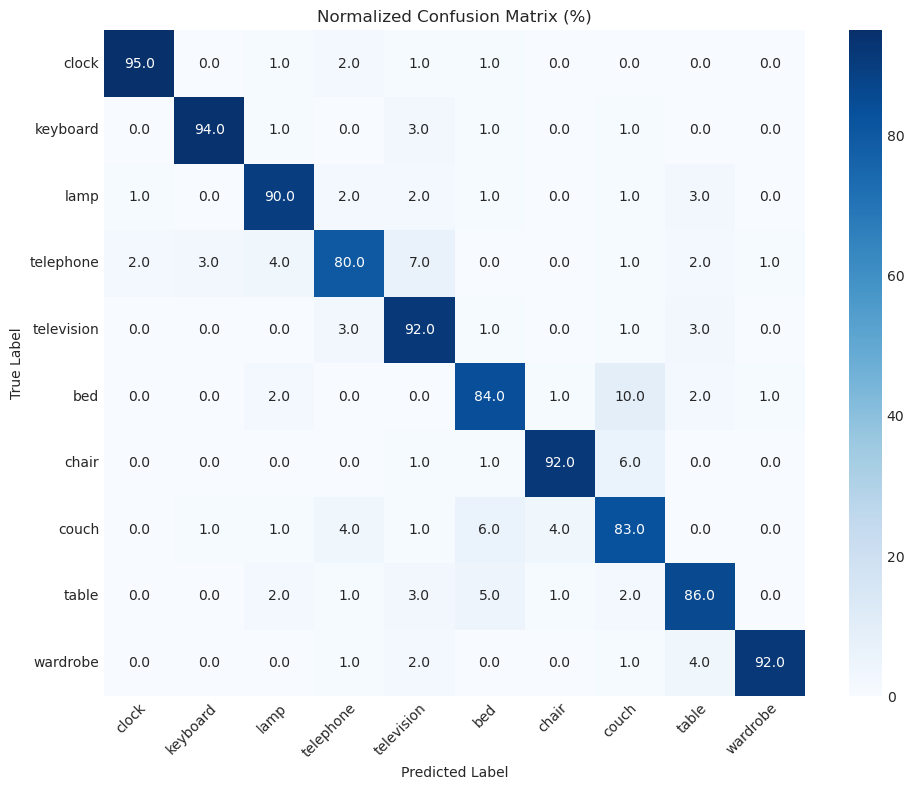

Training history plot saved to ./results/baseline_mobilenet/training_history.png


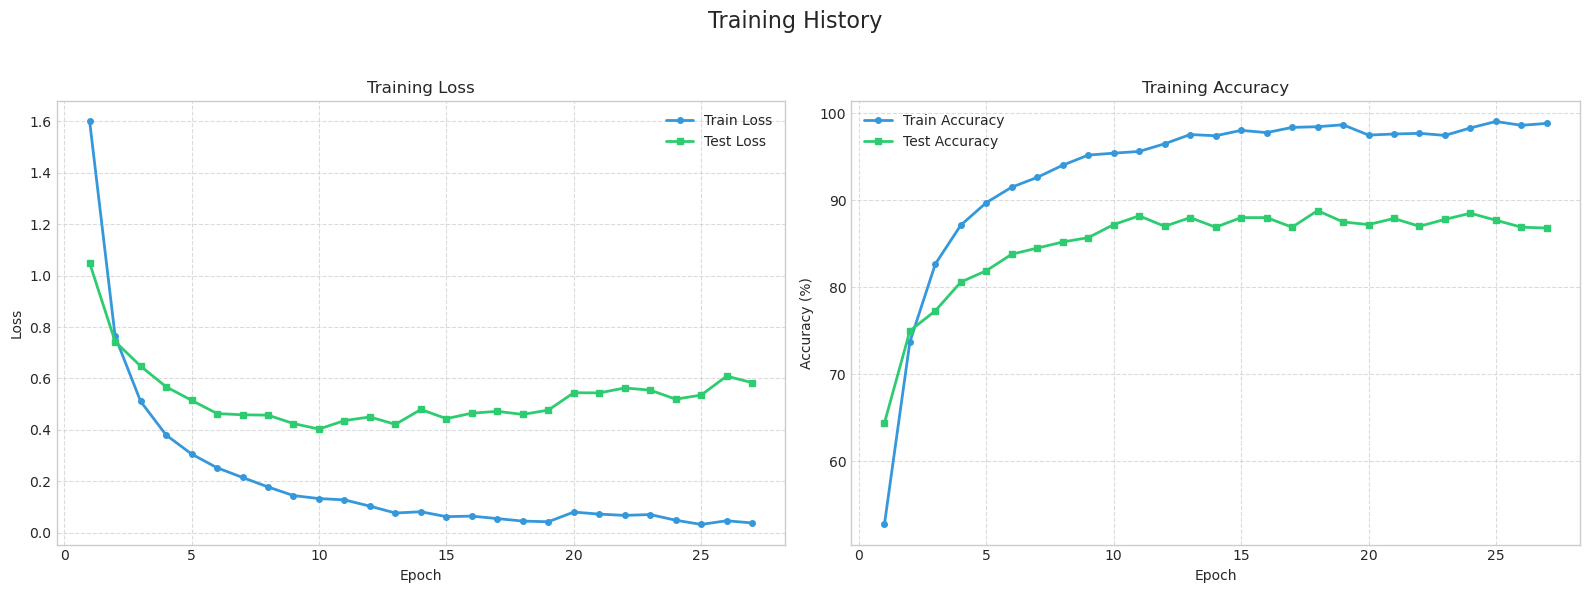

Weight distribution plot saved to ./results/baseline_mobilenet/weight_distribution.png


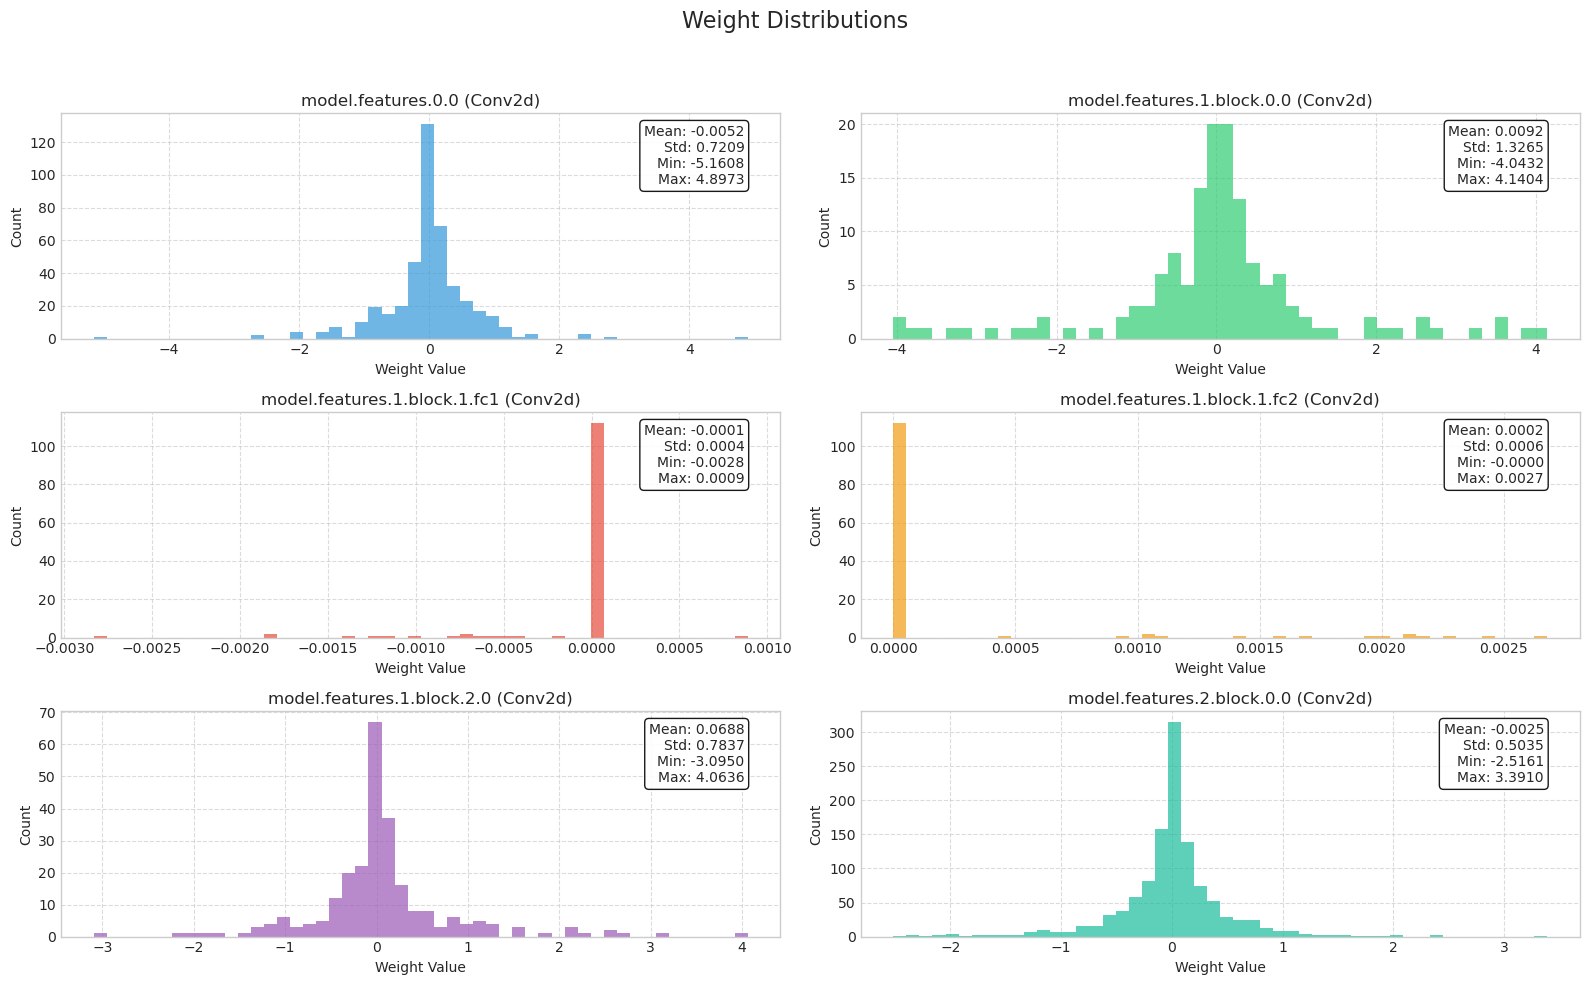

In [11]:
# Load the best model
model = load_model(f"{models_ckp_dir}/model.pth", device)

# Define evaluation input and output variables
class_names = test_loader.dataset.classes
n_classes = len(class_names)
input_size = get_input_size("CIFAR")

# Calculate and save model performance on all metrics
print("Evaluating model's performance on all metrics...")
baseline_metrics = evaluate_model_metrics(model, test_loader, device, n_classes, class_names, input_size, save_path=f"{results_dir}/metrics.json")

# Calculate, plot, and save confusion matrix
confusion_matrix = calculate_confusion_matrix(model, test_loader, device, n_classes)
_ = plot_confusion_matrix(confusion_matrix, class_names, f"{results_dir}/confusion_matrix.png")

# Plot and save training history
_ = plot_training_history(training_stats, f"{results_dir}/training_history.png")

# Plot weight distribution (can help guide optimization strategies)
_ = plot_weight_distribution(model, output_path=f"{results_dir}/weight_distribution.png", num_layers=6)

### Step 5. Identify potential optimization approaches
Based on our baseline analysis, let's identify promising optimization approaches.

In [12]:
print(f"\nAll artifacts saved to:")
print(f" - Model: {models_ckp_dir}/model.pth")
print(f" - Metrics: {results_dir}/metrics.json")
print(f" - Confusion Matrix: {results_dir}/confusion_matrix.png")
print(f" - Training History: {results_dir}/training_history.png")
print(f" - Training Stats: {results_dir}/training_stats.json")
print(f" - Weight Distribution: {results_dir}/weight_distribution.png")


All artifacts saved to:
 - Model: ./models/baseline_mobilenet/checkpoints/model.pth
 - Metrics: ./results/baseline_mobilenet/metrics.json
 - Confusion Matrix: ./results/baseline_mobilenet/confusion_matrix.png
 - Training History: ./results/baseline_mobilenet/training_history.png
 - Training Stats: ./results/baseline_mobilenet/training_stats.json
 - Weight Distribution: ./results/baseline_mobilenet/weight_distribution.png


In [13]:
# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Optimization Targets:
Target Model Size: 5.96 --> 4.17 MB (30.0% reduction)
Target Inference Time (CPU): 9.01 --> 5.41 ms (40.0% reduction)
Target Inference Time (GPU): 6.98 --> 4.19 ms (40.0% reduction)
Minimum Acceptable Accuracy: 88.80 --> 84.36 (within 5.0% of baseline)


---------

**Analyze the baseline results and select appropriate compression techniques**

Now that you've established the baseline performance metrics for the UdaciSense object recognition model, complete an analysis that explores the optimization potential for this specific model architecture.

Consider these guiding questions:
- What is the baseline performance we need to optimize from?
- What characteristics of MobileNetV3 affect its optimization potential?
- Which compression techniques are most promising for this architecture and why?
- What trade-offs do you anticipate between size, speed, and accuracy?
- How might different techniques complement each other in a multi-stage approach?

Provide a well-reasoned analysis that includes recommendations for at least two specific compression techniques to implement in the next notebook.

## Optimization Analysis for UdaSense Computer Vision Model

### 1. Training Dynamics and Generalization Behavior

The training history indicates:

#### 1.1 Rapid convergence

Training loss decreases sharply within the first few epochs and continues to decline smoothly. This implies:

* the model learns the classification task quickly
* the optimizer finds a stable descent path
* the network likely has more capacity than strictly required

#### 1.2 Generalization gap

Training accuracy climbs toward 97–98 percent, while test accuracy stabilizes around 85–87 percent and fluctuates slightly.

Interpretation:

* the model generalizes reasonably well but shows mild overfitting
* the capacity of the network appears larger than needed for the dataset
* this is consistent with the weight distribution findings, where several layers show suppressed or near-zero weights

#### 1.3 Stable plateau in test metrics

The test accuracy plateaus early and remains stable, indicating:

* the model has learned essentially all information available in the dataset
* additional training does not meaningfully improve performance
* the architecture probably contains redundancy that contributes to overcapacity but not to better accuracy

This matches the weight distribution: the network is effectively ignoring some filters.

---

### 2. Structural Analysis: Weight Distributions

We inspected two representative layers. They reveal two different but complementary phenomena:

#### 2.1 Case A: Broad Gaussian-like weight distribution around zero

This type of distribution shows that:

* many weights have small but nonzero contributions
* the layer is not collapsed or dead
* the distribution resembles a typical well-trained convolutional layer
* redundancy is present because most values cluster near zero
* the layer is highly suitable for **magnitude-based pruning**
* the layer is **quantization-friendly**, because values occupy a narrow range around zero

This is classical compression potential due to overparameterization.

#### 2.2 Case B: Degenerate near-zero distribution

The second example shows a much more extreme pattern:

* mean and std essentially zero
* almost all values exactly at or extremely near zero
* only a handful of weak outliers
* the weight histogram collapses into a vertical line at 0

This implies:

* the layer is effectively dormant
* the contribution to feature extraction is negligible
* upstream layers or residual connections provide sufficient signal
* the layer can be aggressively pruned, potentially even removed
* structured pruning (entire filters or entire conv operations) is realistic
* quantization will introduce almost no error

A distribution like this is one of the clearest signs of superfluous computation.

---

### 3. Compression Technique Suitability

Based on training behavior and weight statistics, we can evaluate the main compression techniques:

#### 3.1 Unstructured Pruning

Highly effective here.

Why?

* the baseline shows many small-magnitude weights
* the network is moderately overfitted
* several layers contain extremely collapsed weights
* pruning should not heavily impact test accuracy if applied with a conservative threshold and iterative fine-tuning

Expected benefit:

* model size reduction between 30 to 60 percent
* improved inference speed on CPU architectures
* minimal accuracy drop if applied properly

#### 3.2 Structured Pruning (channels, filters, blocks)

Feasible for selected layers.

Layers with collapsed distributions are ideal candidates for filter pruning.

Expected benefits:

* direct speedup on GPU and mobile hardware
* reduced memory footprint
* simplified architecture for later deployment

However:

* should not be applied uniformly across all layers
* requires layer-by-layer sensitivity evaluation
* risky if applied to early feature extractors unless analysis confirms redundancy

Structured pruning is more impactful than unstructured pruning in terms of latency, but requires more care.

#### 3.3 Post-Training Quantization (PTQ)

Very good candidate.

Reasons:

* symmetric, narrow weight distributions
* very few outliers
* stable activation patterns
* convergence behavior is smooth
* the model is not highly sensitive to weight perturbations

INT8 PTQ should preserve accuracy well. INT4 may work for some layers, especially those with collapsed distributions.

Expected benefits:

* model size reduction by 4 times
* inference speed boost (especially on mobile or CPU backends)

Given the model’s stable behavior and low curvature in the loss landscape, PTQ before QAT is sensible.

#### 3.4 Quantization-Aware Training (QAT)

Use QAT only if:

* PTQ causes more than a 2–3 percent accuracy drop
* the mobile deployment constraints require INT8 inference with strict accuracy ceilings

Given your baseline, PTQ may already achieve acceptable final accuracy.

#### 3.5 Graph-level optimizations

These include operator fusion, kernel folding, and dead-path elimination.

Given dormant layers and redundant weights, graph pruning or ONNX-level simplification may eliminate entire operations produced by structured pruning.

Good but secondary to pruning and quantization.

---

### 4. Should We Use Knowledge Distillation?

We evaluate distillation based on evidence:

#### Signals in favor of distillation

* the teacher model’s capacity exceeds the dataset’s complexity
* the teacher achieves high confidence and stable predictions
* some layers appear unused, implying available redundancy
* distillation can sometimes smooth uneven decision boundaries

#### Signals *against* distillation

* the teacher already generalizes only to ~85–87 percent test accuracy
* distillation works best when the teacher is significantly better than the student and the dataset does not fully reveal structural patterns
* compression through pruning is already extremely promising here
* distillation introduces training overhead and complexity
* the performance ceiling is dominated by dataset limits, not lack of representation power

#### Conclusion on distillation

Despite the signals against distillation we will try it out.

---

### 5. Final Recommendation

Based on all findings:

#### **Primary Compression Path**

1. Post-training **magnitude pruning** (iterative)
2. Filter-level **structured pruning** on collapsed layers
3. INT8 **post-training quantization**
4. Optional: ONNX-level **graph optimization**

This path yields:

* good adherence to CTO requirements
* minimal engineering complexity
* maximal impact on latency and size

#### **Secondary / Optional Path**

* QAT only if PTQ accuracy loss is unacceptable
* Distillation only if you shrink the model so aggressively that the student needs help compensating for lost capacity

---

> 🚀 **Next Step:** 
> Experiment with the compression techniques you've chosen in notebook `02_compression.ipynb`  